### Importing Libraries

In [1]:
from __future__ import print_function
import os
import re
import tqdm
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras

### Reading Data

In [2]:
train_variant = pd.read_csv("msk-redefining-cancer-treatment/training_variants")
test_variant = pd.read_csv("msk-redefining-cancer-treatment/test_variants")
train_text = pd.read_csv("msk-redefining-cancer-treatment/training_text", sep="\|\|", engine='python', header=None, skiprows=1, names=["ID","Text"])
test_text = pd.read_csv("msk-redefining-cancer-treatment/test_text", sep="\|\|", engine='python', header=None, skiprows=1, names=["ID","Text"])


/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


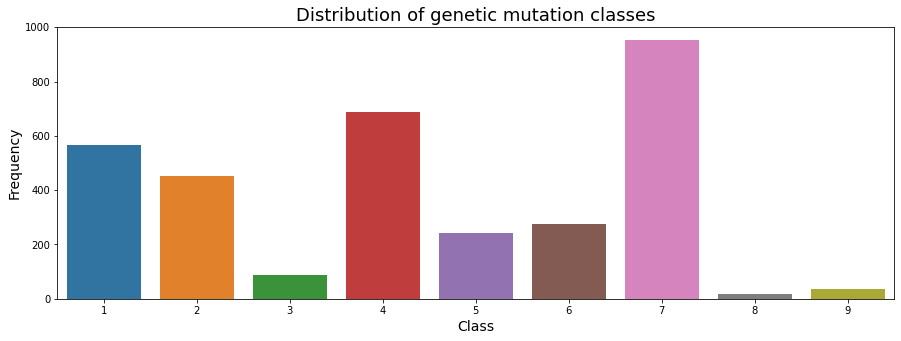

In [3]:
import seaborn as sns
color = sns.color_palette()
plt.figure(figsize=(15,5))
sns.countplot(train_variant.Class,data = train_variant)
plt.ylabel('Frequency', fontsize=14)
plt.xlabel('Class', fontsize=14)
plt.title("Distribution of genetic mutation classes", fontsize=18)
plt.show()

In [4]:
gene_group = train_variant.groupby("Gene")['Gene'].count()
minimal_occ_genes = gene_group.sort_values(ascending=True)[:10]
print("Genes with maximal occurences\n", gene_group.sort_values(ascending=False)[:10])
print("\nGenes with minimal occurences\n", minimal_occ_genes)

Genes with maximal occurences
 Gene
BRCA1     264
TP53      163
EGFR      141
PTEN      126
BRCA2     125
KIT        99
BRAF       93
ALK        69
ERBB2      69
PDGFRA     60
Name: Gene, dtype: int64

Genes with minimal occurences
 Gene
KLF4      1
FGF19     1
FANCC     1
FAM58A    1
PAK1      1
ERRFI1    1
PAX8      1
PIK3R3    1
PMS1      1
PPM1D     1
Name: Gene, dtype: int64


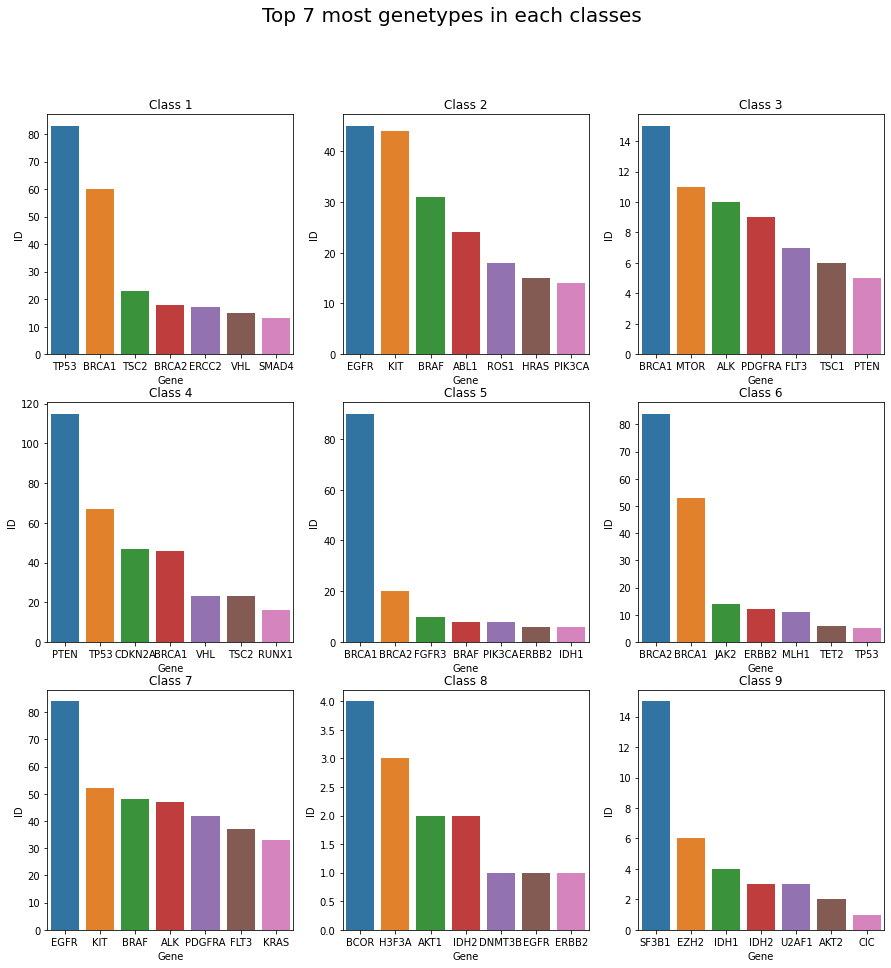

In [5]:
fig, axs = plt.subplots(ncols=3, nrows=3, figsize=(15,15))
# plt.title("Distribution of genetic mutation classes")
plt.suptitle('Top 7 most genetypes in each classes',fontsize=20)
axs[0, 0].set_title('Class 1')
axs[0, 1].set_title('Class 2')
axs[0, 2].set_title('Class 3')
axs[1, 0].set_title('Class 4')
axs[1, 1].set_title('Class 5')
axs[1, 2].set_title('Class 6')
axs[2, 0].set_title('Class 7')
axs[2, 1].set_title('Class 8')
axs[2, 2].set_title('Class 9')
for i in range(3):
    for j in range(3):
        gene_count_grp = train_variant[train_variant["Class"]==((i*3+j)+1)].groupby('Gene')["ID"].count().reset_index()
        sorted_gene_group = gene_count_grp.sort_values('ID', ascending=False)
        sorted_gene_group_top_7 = sorted_gene_group[:7]
        sns.barplot(x="Gene", y="ID", data=sorted_gene_group_top_7, ax=axs[i][j])

plt.show()

In [6]:
train = pd.merge(train_variant, train_text, how='left', on='ID')
train_y = train['Class'].values
train_x = train.drop('Class', axis=1)
test_x = pd.merge(test_variant, test_text, how='left', on='ID')

In [7]:
train.head()

,ID,Gene,Variation,Class,Text
0,0,FAM58A,Truncating Mutations,1,Cyclin-dependent kinases (CDKs) regulate a var...
1,1,CBL,W802*,2,Abstract Background Non-small cell lung canc...
2,2,CBL,Q249E,2,Abstract Background Non-small cell lung canc...
3,3,CBL,N454D,3,Recent evidence has demonstrated that acquired...
4,4,CBL,L399V,4,Oncogenic mutations in the monomeric Casitas B...


In [8]:
train_size=len(train_x)
train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3321 entries, 0 to 3320
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         3321 non-null   int64 
 1   Gene       3321 non-null   object
 2   Variation  3321 non-null   object
 3   Class      3321 non-null   int64 
 4   Text       3316 non-null   object
dtypes: int64(2), object(3)
memory usage: 155.7+ KB


In [9]:
test_size=len(test_x)
test_x.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5668 entries, 0 to 5667
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         5668 non-null   int64 
 1   Gene       5668 non-null   object
 2   Variation  5668 non-null   object
 3   Text       5667 non-null   object
dtypes: int64(1), object(3)
memory usage: 221.4+ KB


In [10]:
test_index = test_x['ID'].values
all_data = np.concatenate((train_x, test_x), axis=0)
all_data = pd.DataFrame(all_data)
all_data.columns = ["ID", "Gene", "Variation", "Text"]

In [11]:
all_data.head()

,ID,Gene,Variation,Text
0,0,FAM58A,Truncating Mutations,Cyclin-dependent kinases (CDKs) regulate a var...
1,1,CBL,W802*,Abstract Background Non-small cell lung canc...
2,2,CBL,Q249E,Abstract Background Non-small cell lung canc...
3,3,CBL,N454D,Recent evidence has demonstrated that acquired...
4,4,CBL,L399V,Oncogenic mutations in the monomeric Casitas B...


### Data Preprocessing

In [12]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
from nltk.corpus import stopwords
from gensim.models.doc2vec import TaggedDocument
from gensim import utils

def constructLabeledSentences(data):
    sentences=[]
    for index, row in data.iteritems():
        sentences.append(TaggedDocument(utils.to_unicode(row).split(), ['Text' + '_%s' % str(index)]))
    return sentences

def textClean(text):
    text = re.sub(r"[^A-Za-z0-9^,!.\/'+-=]", " ", str(text))
    text = text.lower().split()
    stops = set(stopwords.words("english"))
    text = [w for w in text if not w in stops]    
    text = " ".join(text)
    return(text)
def cleanup(text):
    text = textClean(text)
    text= text.translate(str.maketrans("","", string.punctuation))
    return text

allText = all_data["Text"].apply(cleanup)
sentences = constructLabeledSentences(allText)
allText.head()

0    cyclindependent kinases cdks regulate variety ...
1    abstract background nonsmall cell lung cancer ...
2    abstract background nonsmall cell lung cancer ...
3    recent evidence demonstrated acquired uniparen...
4    oncogenic mutations monomeric casitas blineage...
Name: Text, dtype: object

### Data Preparation and Features Extraction

#### Text Featurizer using Doc2Vec

Training Doc2Vec with your data or use an existing model

In [14]:
from gensim.models import Doc2Vec

Text_INPUT_DIM=300


text_model=None
filename='docEmbeddings.d2v'
if os.path.isfile(filename):
    text_model = Doc2Vec.load(filename)
else:
    text_model = Doc2Vec(min_count=1, window=5, vector_size=Text_INPUT_DIM, sample=1e-4, negative=5, workers=4, epochs=5,seed=1)
    text_model.build_vocab(sentences)
    text_model.train(sentences, total_examples=text_model.corpus_count, epochs=text_model.epochs)
    text_model.save(filename)

Featurize text for your training and testing dataset

In [15]:
text_train_arrays = np.zeros((train_size, Text_INPUT_DIM))
text_test_arrays = np.zeros((test_size, Text_INPUT_DIM))

for i in range(train_size):
    text_train_arrays[i] = text_model.docvecs['Text_'+str(i)]

j=0
for i in range(train_size,train_size+test_size):
    text_test_arrays[j] = text_model.docvecs['Text_'+str(i)]
    j=j+1
    
print(text_train_arrays[0][:50])

[ 0.52156401 -0.39561817  0.25546029  0.29260504 -0.34427023  0.03792409
 -0.29784194  0.95752829  0.47737324  0.67540443 -0.42019928 -1.1432333
 -0.37589902  1.79869878  0.18773338 -0.18986957 -0.25080296 -0.46951947
  0.73351008 -0.30842453 -0.00522576  0.15642609 -0.14448187  0.41786098
 -0.06562584 -1.45883274  0.58108819  0.91978574 -0.57038462 -0.18701246
  0.1085549  -0.23018582 -0.28366211  0.02392927  0.23596349 -0.57987839
  0.81395125  0.1462857   0.96545666  0.15252252 -1.02634871 -0.47518092
 -0.01132111 -0.36787632  0.06752639  0.11485472  0.11377909 -0.16359709
 -0.63103527 -0.03638198]


#### Gene and Varation Featurizer

In [16]:
from sklearn.decomposition import TruncatedSVD
Gene_INPUT_DIM=25

svd = TruncatedSVD(n_components=25, n_iter=Gene_INPUT_DIM, random_state=12)

one_hot_gene = pd.get_dummies(all_data['Gene'])
truncated_one_hot_gene = svd.fit_transform(one_hot_gene.values)

one_hot_variation = pd.get_dummies(all_data['Variation'])
truncated_one_hot_variation = svd.fit_transform(one_hot_variation.values)

In [17]:
from keras.utils import np_utils
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(train_y)
encoded_y = np_utils.to_categorical((label_encoder.transform(train_y)))


In [18]:
train_set=np.hstack((truncated_one_hot_gene[:train_size],truncated_one_hot_variation[:train_size],text_train_arrays))
test_set=np.hstack((truncated_one_hot_gene[train_size:],truncated_one_hot_variation[train_size:],text_test_arrays))

### Defining Keras Model

In [19]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Embedding, Input, RepeatVector
from keras.optimizers import gradient_descent_v2

def baseline_model():
    model = Sequential()
    model.add(Dense(256, input_dim=Text_INPUT_DIM+Gene_INPUT_DIM*2, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(80,  activation='relu'))
    model.add(Dense(9, activation="softmax"))
    
    sgd = gradient_descent_v2.SGD(learning_rate=0.01, decay=1e-6, momentum=0.9, nesterov=True)  
    model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])
    return model

In [20]:
model = baseline_model()
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               89856     
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (None, 80)                20560     
                                                                 
 dense_3 (Dense)             (None, 9)                 729       
                                                                 
Total params: 176,937
Trainable params: 176,937
Non-trai

### Training and Evaluating the Model

In [21]:
from keras import callbacks
estimator=model.fit(train_set, encoded_y, validation_split=0.2, epochs=50, batch_size=32)

Epoch 1/50
83/83 [==============================] - 1s 7ms/step - loss: 1.7806 - accuracy: 0.3614 - val_loss: 1.6654 - val_accuracy: 0.3549
Epoch 2/50
83/83 [==============================] - 2s 18ms/step - loss: 1.4904 - accuracy: 0.4578 - val_loss: 1.6249 - val_accuracy: 0.3609
Epoch 3/50
83/83 [==============================] - 0s 4ms/step - loss: 1.3601 - accuracy: 0.5056 - val_loss: 1.7590 - val_accuracy: 0.3158
Epoch 4/50
83/83 [==============================] - 0s 5ms/step - loss: 1.2465 - accuracy: 0.5380 - val_loss: 1.8643 - val_accuracy: 0.3173
Epoch 5/50
83/83 [==============================] - 0s 4ms/step - loss: 1.1601 - accuracy: 0.5776 - val_loss: 1.7776 - val_accuracy: 0.3459
Epoch 6/50
83/83 [==============================] - 0s 4ms/step - loss: 1.0971 - accuracy: 0.5994 - val_loss: 1.8341 - val_accuracy: 0.3233
Epoch 7/50
83/83 [==============================] - 0s 3ms/step - loss: 1.0348 - accuracy: 0.6280 - val_loss: 1.9135 - val_accuracy: 0.3534
Epoch 8/50
83/83 [=

In [28]:
from numpy.ma.core import mean
print("Average Training accuracy: %.2f%% and Average Validation accuracy: %.2f%%" % (100*mean(estimator.history['accuracy']), 100*mean(estimator.history['val_accuracy'])))

Average Training accuracy: 77.27% and Average Validation accuracy: 34.12%


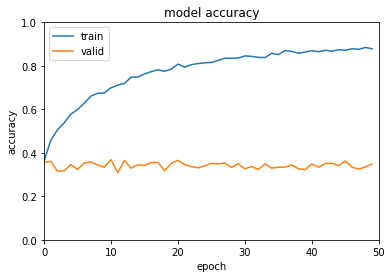

In [25]:
import matplotlib.pyplot as plt

# summarize history for accuracy
plt.plot(estimator.history['accuracy'])
plt.plot(estimator.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.xlim([0, 50])
plt.ylim([0,1])
plt.legend(['train', 'valid'], loc='upper left')
plt.show()

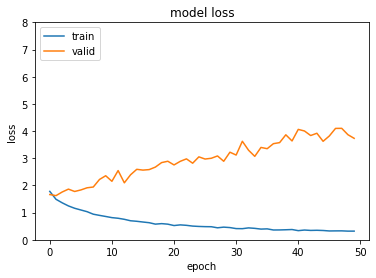

In [27]:
plt.plot(estimator.history['loss'])
plt.plot(estimator.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.ylim([0,8])
plt.legend(['train', 'valid'], loc='upper left')
plt.show()